## Python translation of Liao et al transfer function 

In [1]:
"""
Python translation of trans.m, Transfun.m, Eta_T_r.m, and T_r.m.

Dependencies: numpy, scipy

Functions
---------
T_r                      – steady-state radial temperature profile (spherical shell)
Eta_T_r                  – Arrhenius viscosity as a function of radius
Transfun                 – complex transfer function H(omega) for a viscoelastic shell
trans                    – apply transfer function to an input time series via FFT
polar_decomposition      – compute gain and phase lag over a range of forcing periods
plot_polar_decomposition – plot gain and phase lag vs. period on a log axis
"""

import numpy as np
from scipy import integrate
from scipy.fft import rfft, irfft, rfftfreq
import matplotlib.pyplot as plt

import composite_tools

In [2]:

# ---------------------------------------------------------------------------
# Temperature profile  T_r  (from T_r.m)
# ---------------------------------------------------------------------------

def T_r(r, Tin, Tout, ro, Ro):
    """
    Steady-state radial temperature with spherical symmetry (from T_r.m).

    General shell solution: T(r) = Tin - (Tin-Tout)/(1-ro/Ro)
                                        + (Tin-Tout)/(1/ro-1/Ro) / r
    Special case ro==Ro: T = Tin everywhere.

    Parameters
    ----------
    r   : float or array – radial position (normalised, same units as ro/Ro)
    Tin : float – temperature at inner radius ro  (°C)
    Tout: float – temperature at outer radius Ro  (°C)
    ro  : float – inner radius
    Ro  : float – outer radius

    Returns
    -------
    T : float or array – temperature (°C)
    """
    if ro == Ro:
        return np.full_like(np.asarray(r, dtype=float), Tin)
    r = np.asarray(r, dtype=float)
    return Tin - (Tin - Tout) / (1.0 - ro/Ro) + (Tin - Tout) / (1.0/ro - 1.0/Ro) / r


# ---------------------------------------------------------------------------
# Arrhenius viscosity  Eta_T_r  (from Eta_T_r.m)
# ---------------------------------------------------------------------------

def Eta_T_r(Tin, Tout, ro, Ro, r):
    """
    Radial viscosity profile following DeNegro (2010): eta = Ad * exp(E / R*T).

    Parameters
    ----------
    Tin  : float – temperature at inner radius ro  (°C)
    Tout : float – temperature at outer radius Ro  (°C)
    ro   : float – inner radius
    Ro   : float – outer reference radius (= d in trans/Transfun)
    r    : float or array – radial position(s)

    Returns
    -------
    Eta : float or array – dynamic viscosity (Pa·s)
    """
    Ad = 1e9          # Dorn pre-exponential parameter (Pa·s)
    E  = 120e3        # activation energy (J/mol)
    R  = 8.314        # gas constant (J/mol·K)

    T = T_r(r, Tin, Tout, ro, Ro)          # temperature in °C
    return Ad * np.exp(E / (R * (T + 273.0)))   # convert °C → K


def EtaMelt_T_r(Tin, Tout, ro, Ro, r, Ts):
    """
    Radial melt viscosity profile following Giordano (2008) in VFT form.
    We choose a rhyolite parametrization from Giordano (2008), with form

    log eta = A + B / (T - C),

    which generalizes Arrhenius [where C = 0]. The viscosity is capped at the
    viscosity at solidus to prevent extremely large (overflowing) values of
    viscosity where the temperature is too low to have melt.

    Parameters
    ----------
    Tin  : float – temperature at inner radius ro  (°C)
    Tout : float – temperature at outer radius Ro  (°C)
    ro   : float – inner radius
    Ro   : float – outer reference radius (= d in trans/Transfun)
    r    : float or array – radial position(s)
    Ts   : float - solidus temperature (°C)

    Returns
    -------
    Eta : float or array – dynamic viscosity (Pa·s)
    """
    A = -4.55
    B = 11495
    C = 342

    T = np.clip(T_r(r, Tin, Tout, ro, Ro), Ts, None) # temperature in °C
    logeta = A + B / (T + 273.0 - C)
    return np.exp(logeta)


def Meltfraction(Tin, Tout, ro, Ro, r, Ts, Tl, b):
    """
    Melt fraction parametrized by a power-law between solidus and liquidus.

    Parameters
    ----------
    Tin  : float – temperature at inner radius ro  (°C)
    Tout : float – temperature at outer radius Ro  (°C)
    ro   : float – inner radius
    Ro   : float – outer reference radius (= d in trans/Transfun)
    r    : float or array – radial position(s)
    Ts   : float – solidus temperature  (°C)
    Tl   : float – liquidus temperature  (°C)
    b    : float - melt fraction mapping exponent

    Returns
    -------
    Eta : float or array – melt fraction (unitless)
    """
    T = T_r(r, Tin, Tout, ro, Ro)          # temperature in °C
    return np.clip(((T - Ts) / (Tl - Ts)) ** b, 0, 1)


In [3]:

# ---------------------------------------------------------------------------
# Transfun  (from Transfun.m)
# ---------------------------------------------------------------------------

def Transfun(T_period, ro, d, Tin, Tsurface, Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, include_melt_model):
    """
    Normalised transfer function H with amplitude Amp and phase delay theta.

    Parameters
    ----------
    T_period : float – oscillation period (days)
    ro       : float – inner (chamber) radius; normalised, use ro=1
    d        : float – outer reference radius (same units as ro)
    Tin      : float – temperature at ro  (°C)
    Tsurface : float – temperature at d   (°C)
    Murock   : float – reference rock shear modulus (Pa); ~1e9
    Mumelt   : float – reference melt shear modulus (Pa); ~1e9
    Krock    : float – reference rock bulk modulus (Pa); ~1e9
    Kmelt    : float – reference melt bulk modulus (Pa); ~1e10
    Ts       : float – solidus temperature (C)
    Tl       : float – liquidus temperature (C)
    b        : float - melt fraction mapping exponent

    Returns
    -------
    H     : complex – transfer function
    Amp   : float   – |H|
    theta : float   – phase delay = -angle(H)  (radians)
    """
    omega = 2.0 * np.pi / (T_period * 24.0 * 3600.0)   # rad/s

    def Mu(r):
        """
        Returns complex shear modulus
        """
        if not include_melt_model:
            etarock = Eta_T_r(Tin, Tsurface, ro, d, r)
            return Murock * 1j * omega * etarock / (Murock + 1j * omega * etarock) 
        # Compute radially varying phasic properties
        meltfrac = Meltfraction(Tin, Tsurface, ro, d, r, Ts, Tl, b)
        etarock = Eta_T_r(Tin, Tsurface, ro, d, r)
        etamelt = EtaMelt_T_r(Tin, Tsurface, ro, d, r, Ts)

        roots_num, roots_den, leading_coeff = \
            composite_tools.SphericalInclusion.G_pole_zero(
                Krock, Kmelt, Murock, Mumelt, etarock, etamelt, meltfrac)
        return leading_coeff * ((1j * omega - roots_num[:, np.newaxis]).prod(axis=0)
            / (1j * omega - roots_den[:, np.newaxis]).prod(axis=0))

    def K(r):
        """
        Returns complex bulk modulus
        """
        if not include_melt_model:
            return Krock
        return Krock
        
        # Compute radially varying phasic properties
        meltfrac = Meltfraction(Tin, Tsurface, ro, d, r, Ts, Tl, b)
        etarock = Eta_T_r(Tin, Tsurface, ro, d, r)

        root_num, root_den, leading_coeff = \
            composite_tools.SphericalInclusion.K_pole_zero(
                Krock, Kmelt, Murock, etarock, meltfrac)
        return leading_coeff * (1j * omega - root_num) / (1j * omega - root_den)

    def Kernel(r):
        return 3.0 * K(r) / r**4 / (K(r) + 4.0 * Mu(r) / 3.0)

    # scipy.integrate.quad requires real-valued functions → split re/im
    Int1_real, _ = integrate.quad(lambda r: np.real(Kernel(r)), ro, np.inf, limit=200)
    Int1_imag, _ = integrate.quad(lambda r: np.imag(Kernel(r)), ro, np.inf, limit=200)
    Int1 = Int1_real + 1j * Int1_imag

    # Normalized transfer function (normalization w.r.t meltless rock reference properties)
    H = (4.0 * Murock / (3.0 * Krock + 4.0 * Murock)) / (1.0 - ro**3 * Int1)

    return H, abs(H), -np.angle(H)



In [ ]:
# ---------------------------------------------------------------------------
# trans  (from trans.m)
# ---------------------------------------------------------------------------

def trans(x, dt, ro, d, Tin, Tsurface, Murock, Mumelt, Krock, Kmelt, Ts, Tl, b):
    """
    Filter input time series x through the radial transfer function.

    Parameters
    ----------
    x        : 1-D array – input signal sampled at interval dt (days)
    dt       : float     – sampling interval (days)
    ro       : float     – chamber inner radius (normalised; use 1)
    d        : float     – outer reference radius (same units as ro)
    Tin      : float     – temperature at ro  (°C)
    Tsurface : float     – temperature at d   (°C)
    Murock   : float – reference rock shear modulus (Pa); ~1e9
    Mumelt   : float – reference melt shear modulus (Pa); ~1e9
    Krock    : float – reference rock bulk modulus (Pa); ~1e9
    Kmelt    : float – reference melt bulk modulus (Pa); ~1e10
    Ts       : float – solidus temperature (C)
    Tl       : float – liquidus temperature (C)
    b        : float - melt fraction mapping exponent

    Returns
    -------
    X        : 1-D complex array – one-sided FFT of x
    Y        : 1-D complex array – one-sided FFT of y
    tx       : 1-D array – time axis for x_recons
    ty       : 1-D array – time axis for y
    x        : 1-D array – original input (passed through)
    x_recons : 1-D array – x recovered via FFT round-trip (sanity check)
    y        : 1-D array – filtered output signal
    """


    N  = len(x)
    X  = rfft(x) / N                        # scaled one-sided spectrum
    Ft = rfftfreq(N, d=dt)                   # frequencies in 1/day
    dF = Ft[1] - Ft[0]

    # Round-trip reconstruction of x
    x_recons = irfft(X * N, n=N)
    tx = np.arange(N) * dt

    # Build transfer-function array; skip DC (Ft[0]=0 → infinite period)
    TTr = np.zeros(len(Ft), dtype=complex)
    for jj in range(1, len(Ft)):
        H, _, _ = Transfun(1.0 / Ft[jj], ro, d, Tin, Tsurface, Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, include_melt_model)
        TTr[jj] = H

    # Apply: zero DC, multiply all other bins
    Y = np.concatenate(([0.0 + 0j], X[1:] * TTr[1:]))

    y  = irfft(Y * N, n=N)
    ty = np.arange(N) * dt

    return X, Y, tx, ty, x, x_recons, y


# ---------------------------------------------------------------------------
# Polar decomposition of the transfer function over a period range
# ---------------------------------------------------------------------------

def polar_decomposition(periods_days, ro, d, Tin, Tsurface,
        Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, include_melt_model):
    """
    Compute the polar decomposition of the transfer function H over a range
    of forcing periods.

    H = Amp * exp(i * phi)

    where Amp = |H| is the gain and phi = angle(H) is the phase angle.
    The phase lag (delay) is theta = -phi, following the Transfun convention.

    Parameters
    ----------
    periods_days : 1-D array  – forcing periods to evaluate (days)
    ro           : float      – inner (chamber) radius; normalised, use ro=1
    d            : float      – outer reference radius (same units as ro)
    Tin          : float      – temperature at ro  (°C)
    Tsurface     : float      – temperature at d   (°C)
    Murock   : float – reference rock shear modulus (Pa); ~1e9
    Mumelt   : float – reference melt shear modulus (Pa); ~1e9
    Krock    : float – reference rock bulk modulus (Pa); ~1e9
    Kmelt    : float – reference melt bulk modulus (Pa); ~1e10
    Ts       : float – solidus temperature (C)
    Tl       : float – liquidus temperature (C)
    b        : float - melt fraction mapping exponent

    Returns
    -------
    H     : 1-D complex array – transfer function at each period
    Amp   : 1-D float array   – gain |H|
    theta : 1-D float array   – phase lag -angle(H)  (radians)
    phi   : 1-D float array   – phase angle angle(H) (radians)
    """
    H_arr     = np.zeros(len(periods_days), dtype=complex)
    Amp_arr   = np.zeros(len(periods_days))
    theta_arr = np.zeros(len(periods_days))

    for ii, T_period in enumerate(periods_days):
        H, Amp, theta   = Transfun(T_period, ro, d, Tin, Tsurface, Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, include_melt_model)
        H_arr[ii]       = H
        Amp_arr[ii]     = Amp
        theta_arr[ii]   = theta

    phi_arr = np.angle(H_arr)   # phase angle  (= -theta by definition)

    return H_arr, Amp_arr, theta_arr, phi_arr


def plot_polar_decomposition(periods_days, Amp, theta, savepath=None):
    """
    Plot gain and phase lag of the transfer function against forcing period
    on a shared log-scale x-axis.

    Parameters
    ----------
    periods_days : 1-D array – forcing periods (days)
    Amp          : 1-D array – gain |H|
    theta        : 1-D array – phase lag (radians)
    savepath     : str or None – if given, save figure to this path
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    theta_deg = np.degrees(theta)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    fig.suptitle("Transfer function: polar decomposition", fontsize=13)

    # --- Gain ---
    ax1.semilogx(periods_days, Amp, color="C0", linewidth=1.8)
    ax1.set_ylabel("Gain  |H|")
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.axhline(1.0, color="k", linewidth=0.8, linestyle=":")

    # --- Phase lag ---
    ax2.semilogx(periods_days, theta_deg*2*np.pi/360, color="C1", linewidth=1.8)
    ax2.set_ylabel("Phase lag  θ  (radian)")
    ax2.set_xlabel("Forcing period (days)")
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.axhline(0.0, color="k", linewidth=0.8, linestyle=":")

    # Annotate period axis with human-readable tick labels
    ax2.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: (f"{x:.0f} d" if x < 365 else f"{x/365:.1f} yr")
    ))
    # Place minor ticks at a few named periods
    named = {"1 d": 1, "1 wk": 7, "1 mo": 30.4, "1 yr": 365, "5 yr": 1825, "10 yr": 3650}
    ax2.set_xticks(list(named.values()), minor=False)
    ax2.set_xticklabels(list(named.keys()))

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150)
        print(f"Saved to {savepath}")
    plt.show()
    return fig

In [ ]:
ro       = 1.0     # normalised inner radius
d        = 10.0    # outer reference radius (same units as ro)
Tin      = 1100.0   # °C at inner radius
Tsurface = 20.0    # °C at outer radius
Krock    = 50e9    # reference rock bulk modulus (Pa)
Kmelt    = 10e9    # reference melt bulk modulus (Pa)
Murock   = 20e9    # reference rock shear modulus (Pa)
Mumelt   = 10e9    # reference melt shear modulus (Pa)
Ts = 850           # °C solidus temperature
Tl = 1100          # °C liquidus temperature
b = 1.0            # melt fraction mapping exponent

<Figure size 2000x600 with 0 Axes>

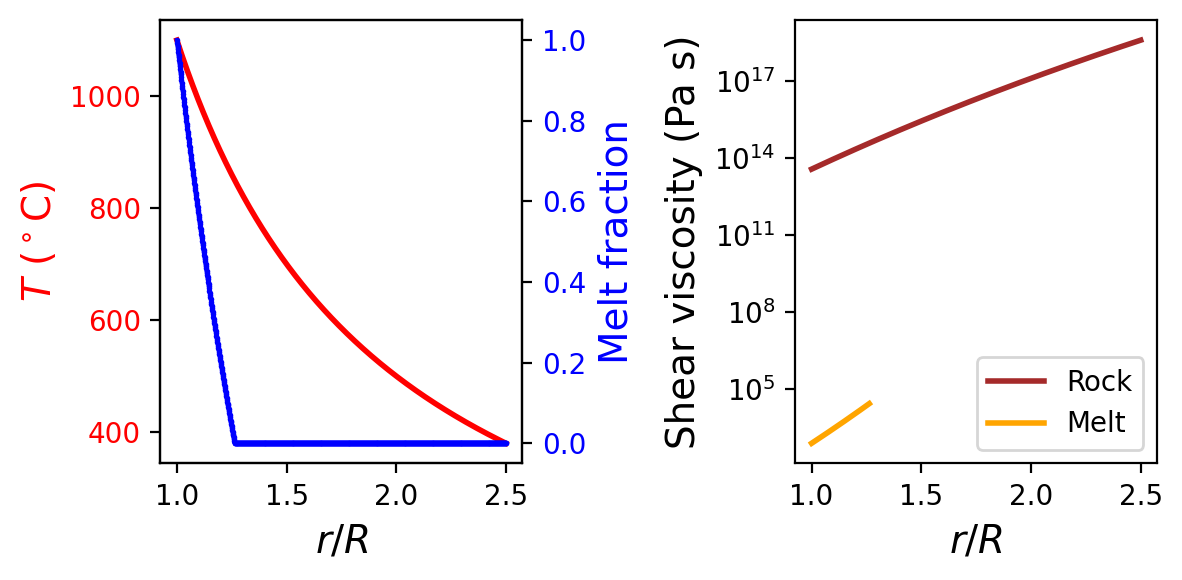

In [84]:
plt.figure(figsize=(10,3), dpi=200)

fig, axes = plt.subplots(1, 2, figsize=(6,3), dpi=200)
r_plot = np.linspace(ro, 2.5*ro, 1000)
T_plot = T_r(r_plot, Tin, Tsurface, ro, d)
Tcolor = np.array([242, 140, 51])/255
axes[0].plot(r_plot, T_plot, color="red", linewidth=2)
axes[0].set_xlabel("$r/R$", fontsize=14)
axes[0].set_ylabel("$T$ (${}^\circ$C)", fontsize=14, color="red")
axes[0].tick_params(axis='y', labelcolor="red")

sec_ax = axes[0].twinx()
meltfraccolor = np.array([132, 205, 232])/255
melt_frac = Meltfraction(Tin, Tsurface, ro, d, r_plot, Ts, Tl, b)
sec_ax.plot(r_plot, melt_frac, '.-', markersize=2, color="blue")
sec_ax.set_ylabel('Melt fraction', color="blue", fontsize=14)
sec_ax.tick_params(axis='y', labelcolor="blue")

# Plot phasic viscosity
etarock = Eta_T_r(Tin, Tsurface, ro, d, r_plot)
etamelt = EtaMelt_T_r(Tin, Tsurface, ro, d, r_plot, Ts)
axes[1].semilogy(r_plot, etarock, label="Rock", color="brown", linewidth=2)
axes[1].semilogy(r_plot, np.where(melt_frac > 0, etamelt, np.nan), label="Melt", color="orange", linewidth=2)
axes[1].set_xlabel("$r/R$", fontsize=14)
axes[1].set_ylabel("Shear viscosity (Pa s)", fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()

C:\Users\Fredric\AppData\Local\Temp\ipykernel_48052\4253291144.py:71: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Int1_real, _ = integrate.quad(lambda r: np.real(Kernel(r)), ro, np.inf, limit=200)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_48052\4253291144.py:72: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Int1_imag, _ = integrate.quad(lambda r: np.imag(Kernel(r)), ro, np.inf, limit=200)


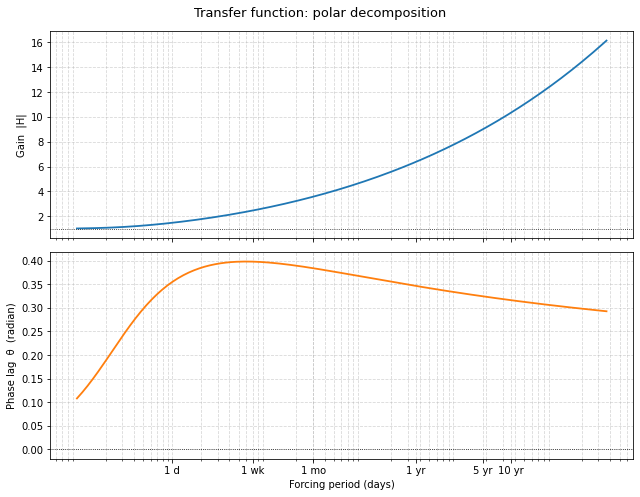

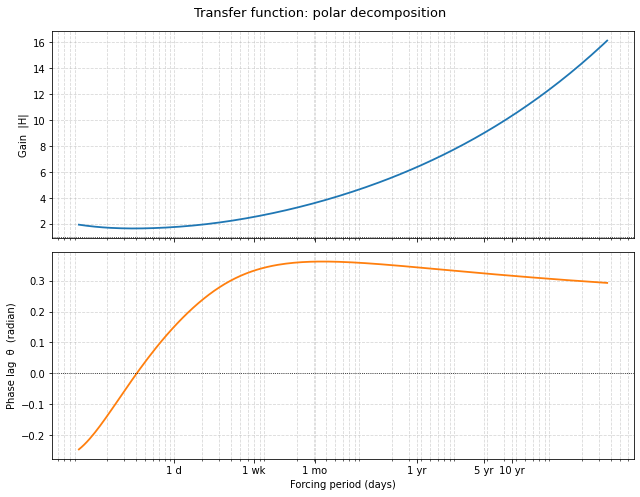

In [ ]:
# --- Gain / phase sweep (log-spaced) ---
periods_days = np.logspace(np.log10(.1), np.log10(100 * 365), 200)   # days

# Calculation with include_melt_model False:
H, Amp, theta, phi = polar_decomposition(periods_days, ro, d, Tin, Tsurface,
        Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, False)
# Calculation with include_melt_model True:
H_melt, Amp_melt, theta_melt, phi_melt = polar_decomposition(periods_days, ro, d, Tin, Tsurface,
        Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, True)
# fig=plot_polar_decomposition(periods_days, Amp, theta)#, savepath="polar_decomposition.png")
# fig=plot_polar_decomposition(periods_days, Amp_melt, theta_melt)#, savepath="polar_decomposition.png")

# --- Time-series filtering Ex ---
# dt = 1.0
# t  = np.arange(0, 365 * 2, dt)
# x  = np.sin(2 * np.pi * t / 365) + 0.5 * np.sin(2 * np.pi * t / 30)

# X, Y, tx, ty, x_in, x_recons, y = trans(x, dt, ro, d, Tin, Tsurface)

# fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
# axes[0].plot(t,  x_in,     label="Input x")
# axes[0].plot(tx, x_recons, "--", label="x reconstructed (FFT round-trip)")
# axes[0].set_ylabel("Amplitude"); axes[0].legend()
# axes[0].set_title("Input signal")

# axes[1].plot(ty, y, color="C2", label="Output y")
# axes[1].set_xlabel("Time (days)"); axes[1].set_ylabel("Amplitude")
# axes[1].legend(); axes[1].set_title("Filtered output")

# plt.tight_layout()
# plt.savefig("trans_output.png", dpi=150)
# plt.show()


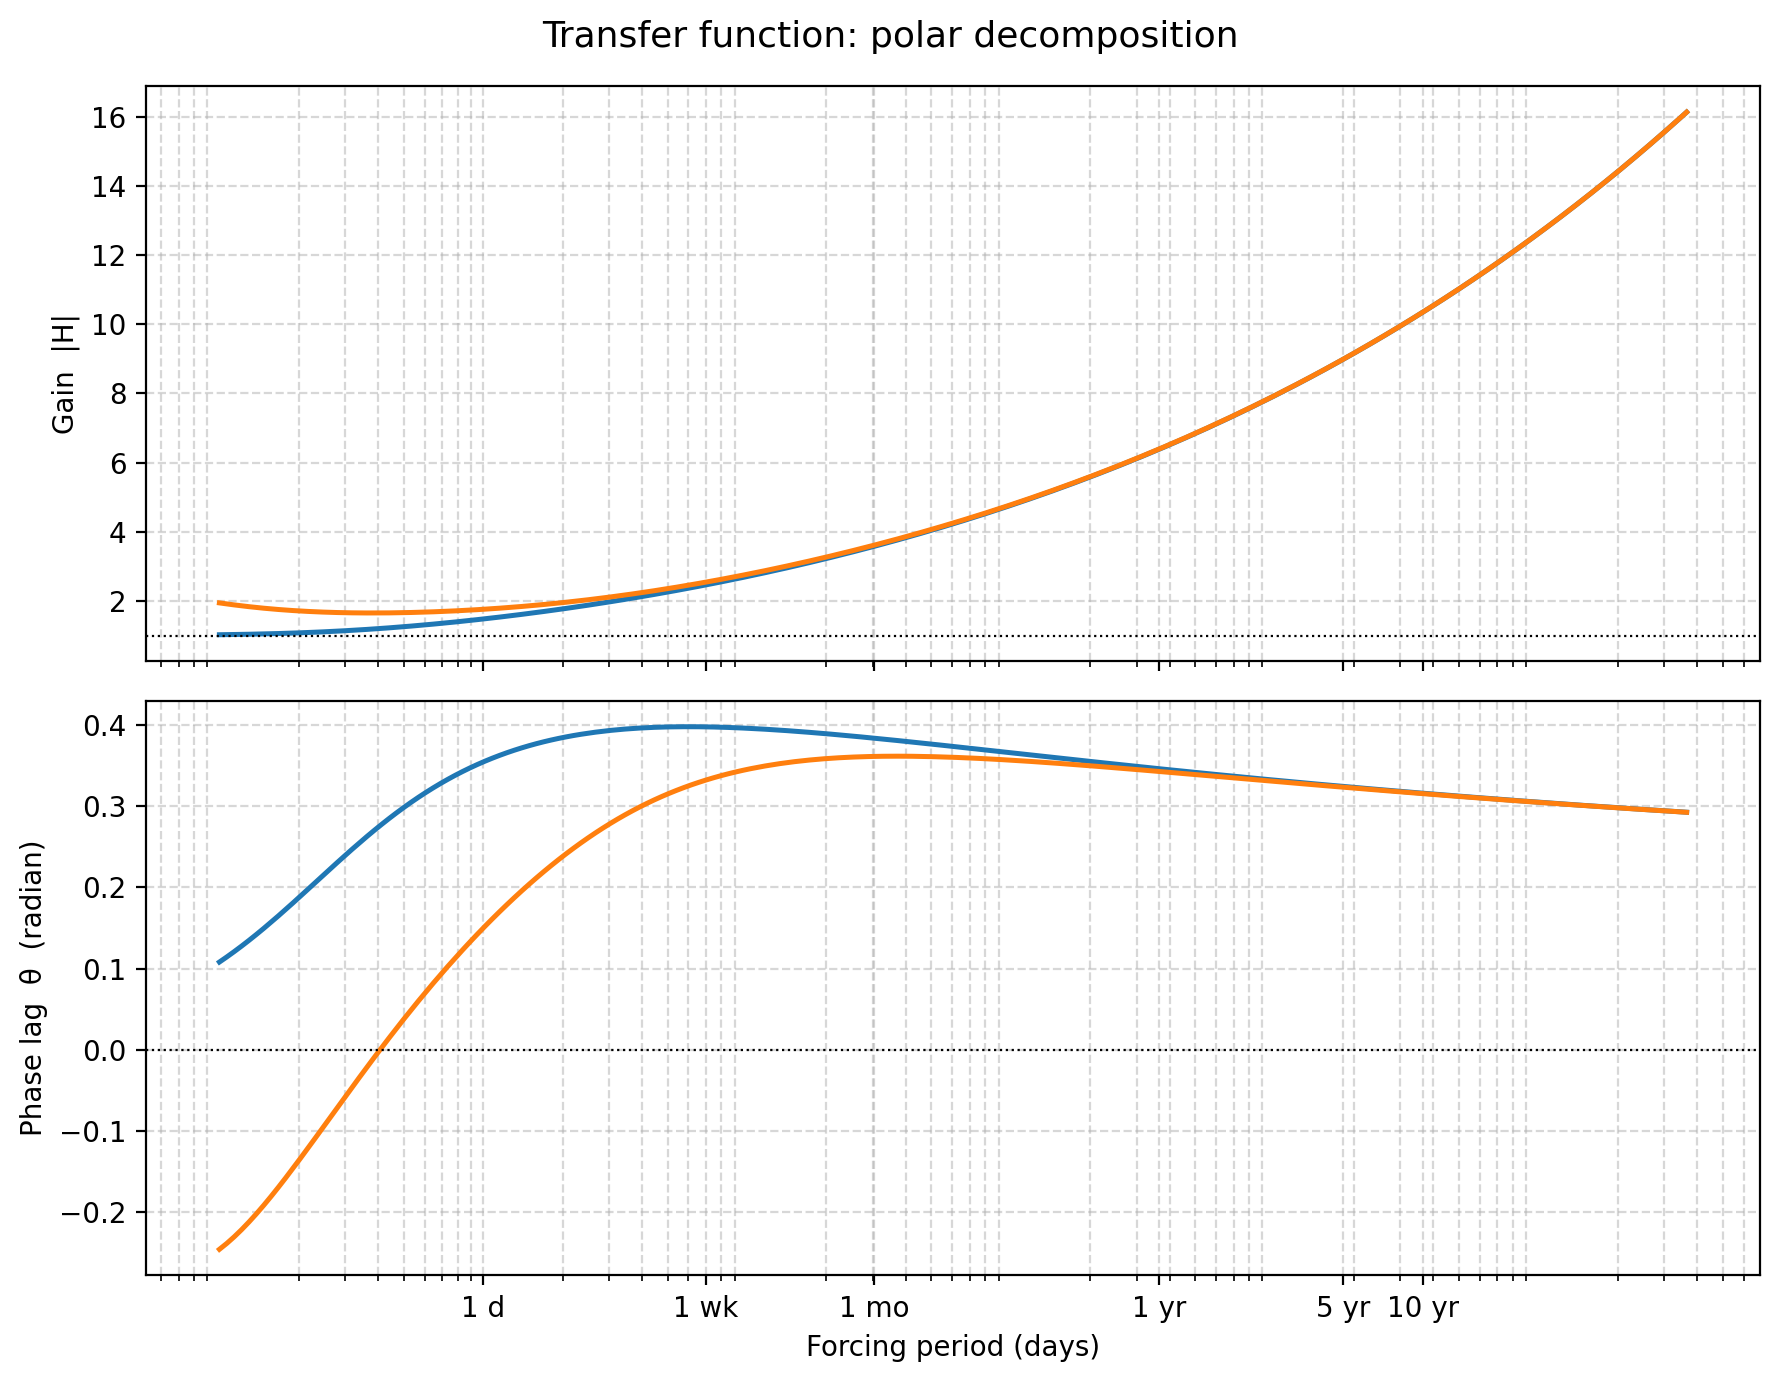

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, dpi=200)
fig.suptitle("Transfer function: polar decomposition", fontsize=13)

# --- Gain ---
ax1.semilogx(periods_days, Amp, color="C0", linewidth=1.8)
ax1.semilogx(periods_days, Amp_melt, color="C1", linewidth=1.8)
ax1.set_ylabel("Gain  |H|")
ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.axhline(1.0, color="k", linewidth=0.8, linestyle=":")

# --- Phase lag ---
ax2.semilogx(periods_days, np.degrees(theta)*2*np.pi/360, color="C0", linewidth=1.8)
ax2.semilogx(periods_days, np.degrees(theta_melt)*2*np.pi/360, color="C1", linewidth=1.8)
ax2.set_ylabel("Phase lag  θ  (radian)")
ax2.set_xlabel("Forcing period (days)")
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.axhline(0.0, color="k", linewidth=0.8, linestyle=":")

# Annotate period axis with human-readable tick labels
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: (f"{x:.0f} d" if x < 365 else f"{x/365:.1f} yr")
))
# Place minor ticks at a few named periods
named = {"1 d": 1, "1 wk": 7, "1 mo": 30.4, "1 yr": 365, "5 yr": 1825, "10 yr": 3650}
ax2.set_xticks(list(named.values()), minor=False)
ax2.set_xticklabels(list(named.keys()))

plt.tight_layout()
plt.show()

In [89]:
# --- Gain / phase sweep (log-spaced) ---
periods_days = np.logspace(np.log10(.1), np.log10(100 * 365), 200)   # days

T_list = [900, 950, 1000, 1050, 1100]
soln_list = []
for i, T in enumerate(T_list):
  # Save tuple (H, Amp, theta, phi) to soln_list
  soln_list.append(polar_decomposition(periods_days, ro, d, T, Tsurface,
    Murock, Mumelt, Krock, Kmelt, Ts, Tl, b, True))

C:\Users\Fredric\AppData\Local\Temp\ipykernel_48052\4253291144.py:72: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Int1_imag, _ = integrate.quad(lambda r: np.imag(Kernel(r)), ro, np.inf, limit=200)
C:\Users\Fredric\AppData\Local\Temp\ipykernel_48052\4253291144.py:71: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Int1_real, _ = integrate.quad(lambda r: np.real(Kernel(r)), ro, np.inf, limit=200)


(0.988362, 0.998364, 0.644924, 1.0)

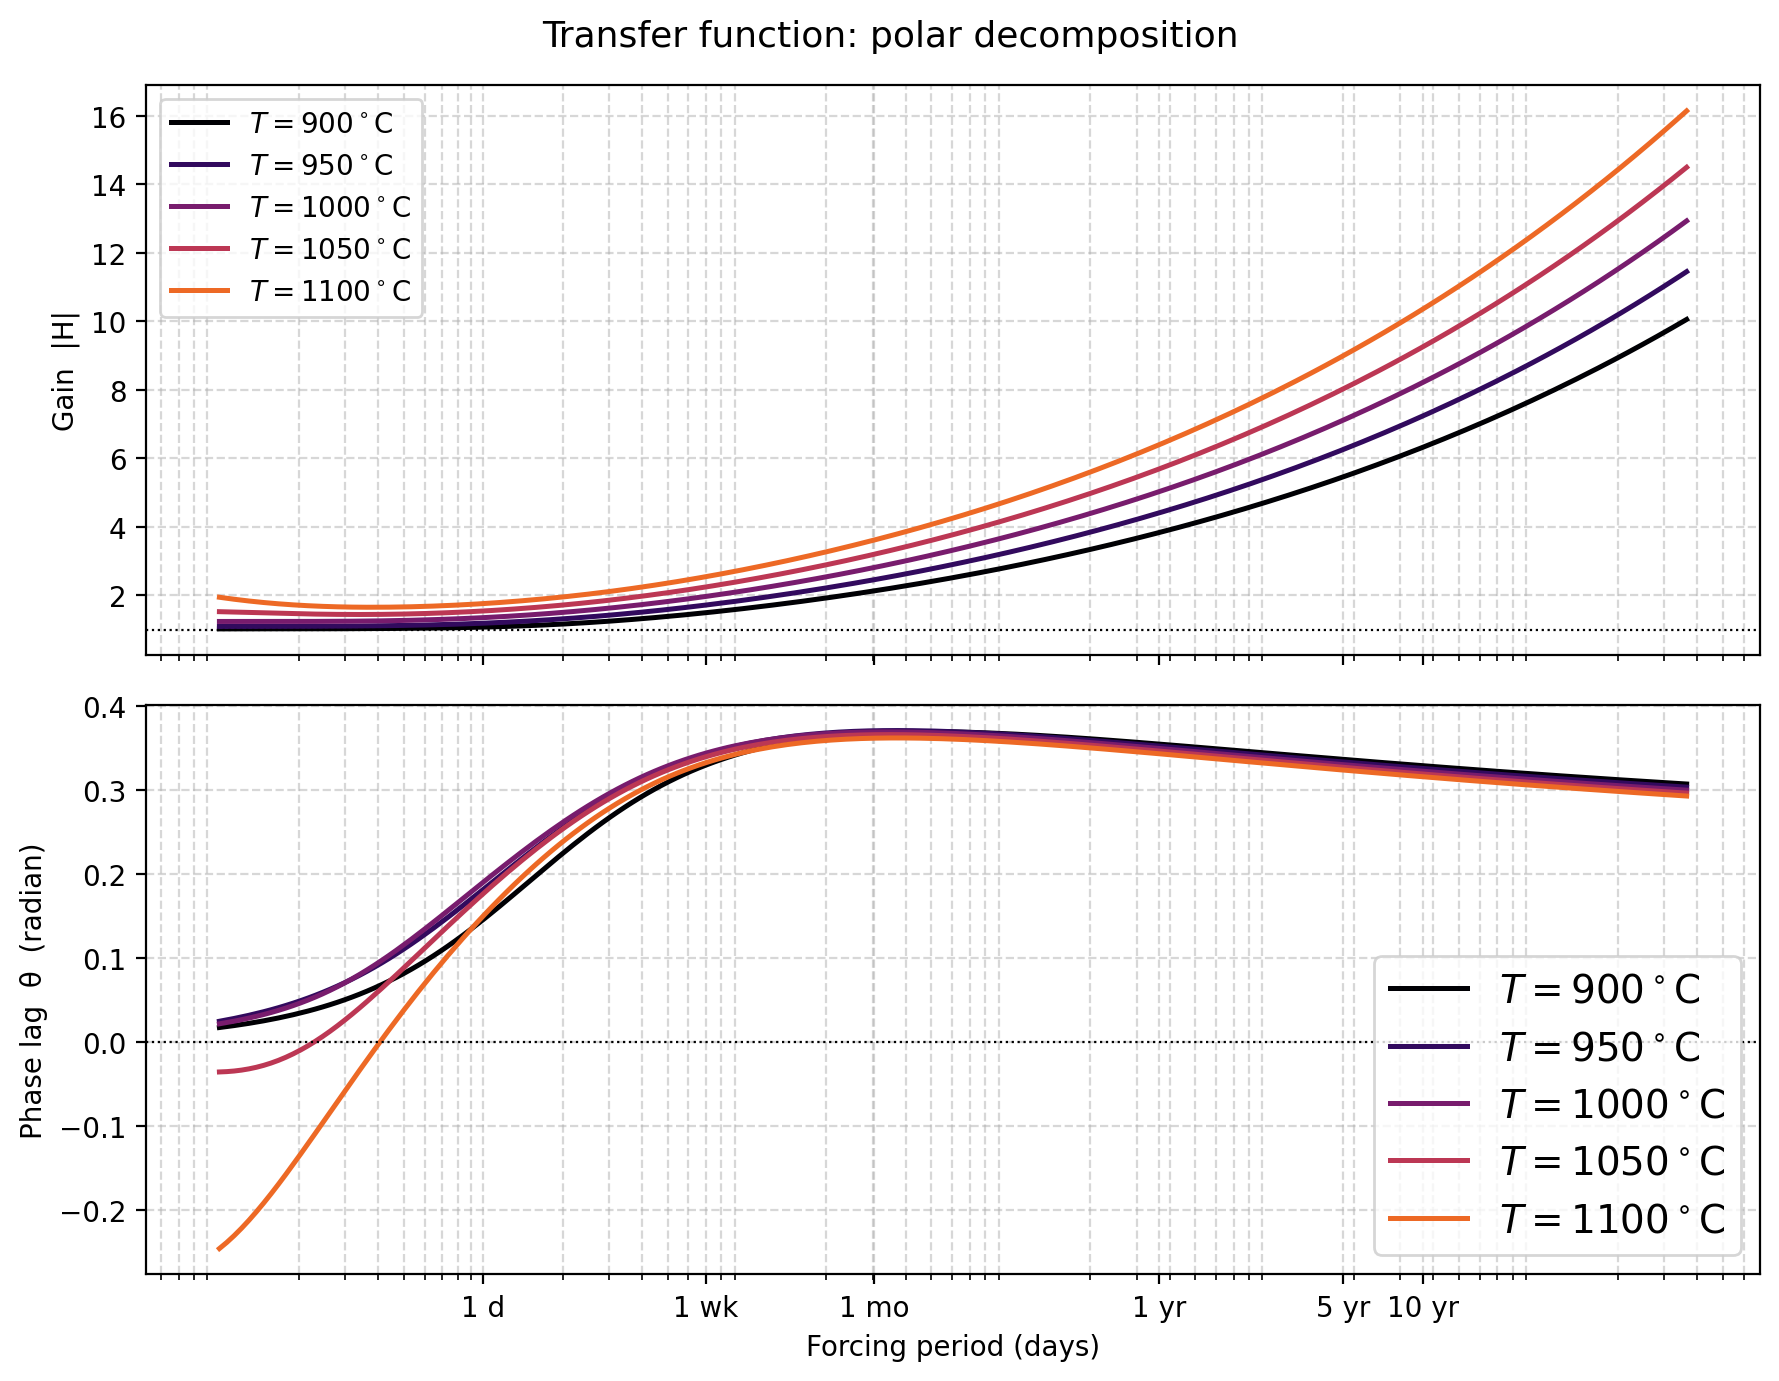

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, dpi=200)
fig.suptitle("Transfer function: polar decomposition", fontsize=13)

# --- Gain ---
for i, soln in enumerate(soln_list):
        # Plot Amp
        ax1.semilogx(periods_days, soln[1], linewidth=1.8,
                color=plt.cm.inferno(i / (len(soln_list)+1)),
                label=f"$T = {T_list[i]}" + "{}^\circ \mathrm{C}$")
ax1.set_ylabel("Gain  |H|")
ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.axhline(1.0, color="k", linewidth=0.8, linestyle=":")
ax1.legend(fontsize=14)

# --- Phase lag ---
for i, soln in enumerate(soln_list):
        # Plot theta
        ax2.semilogx(periods_days, np.degrees(soln[2])*2*np.pi/360,
                linewidth=1.8,
                color=plt.cm.inferno(i / (len(soln_list)+1)),
                label=f"$T = {T_list[i]}" + "{}^\circ \mathrm{C}$")
ax2.set_ylabel("Phase lag  θ  (radian)")
ax2.set_xlabel("Forcing period (days)")
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.axhline(0.0, color="k", linewidth=0.8, linestyle=":")
ax2.legend(fontsize=14)

# Annotate period axis with human-readable tick labels
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: (f"{x:.0f} d" if x < 365 else f"{x/365:.1f} yr")
))
# Place minor ticks at a few named periods
named = {"1 d": 1, "1 wk": 7, "1 mo": 30.4, "1 yr": 365, "5 yr": 1825, "10 yr": 3650}
ax2.set_xticks(list(named.values()), minor=False)
ax2.set_xticklabels(list(named.keys()))

plt.tight_layout()
plt.show()